In [1]:
import numpy as np
import torch
import os
from models.modules import *
from torch.func import jvp, vmap, jacrev
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
x0 = torch.normal(0, 1, size=(50, 2))
x1 = torch.normal(0, 1, size=(50, 2))
c = torch.zeros(50, 2)

In [3]:
def pad_t_like_x(t, x):
    if isinstance(t, (float, int)):
        return t
    return t.reshape(-1, *([1] * (x.dim() - 1)))

In [4]:
model = TimeNet(input_dim=2 * 2,
                  cond_dim=2,
                  output_dim=2,
                  hidden_dims=[50]*2)

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
x0_x1 = torch.cat([x0, x1], dim=-1)

losses = []
for k in range(10000):
    optimizer.zero_grad()

    t = torch.rand(x0.shape[0], requires_grad=True)
    t = pad_t_like_x(t, x0)
    gamma = (1 - t**2 - (1-t)**2)
    d_gamma = 2 * (-2 * t + 1)
    phi = model(x0_x1, c, t)

    xt = (1-t) * x0 + t * x1 + gamma * phi

    # dxt = torch.autograd.grad(
    #         xt,
    #         t,
    #         grad_outputs=torch.ones_like(xt),
    #         create_graph=True,
    #         retain_graph=True,
    #     )[0]

    # def vel(x_0, x_1, t):
    #     x_0 = x_0.unsqueeze(0)
    #     x_1 = x_1.unsqueeze(0)
    #     c_ = c[0].unsqueeze(0)
    #     t = t.unsqueeze(0)
    #     path = model(torch.cat([x_0, x_1], dim=1), c_, t).squeeze(0)
    #     x_t, dx_t = jvp(
    #         path,
    #         (t,),
    #         (torch.ones_like(t).to(t),),
    #     )
    #     return x_t, dx_t
    
    # x_t, dx_t = vmap(vel)(x0, x1, t)
    # print("a")
    # print(x_t.shape, dx_t.shape)
    # break

    dxt = []
    for j in range(xt.shape[1]):  # xt is (B, 2)
        grad_j = torch.autograd.grad(
            outputs=xt[:, j],
            inputs=t,
            grad_outputs=torch.ones_like(t[:, 0]),  # shape (B,)
            retain_graph=True,
            create_graph=True,
        )[0]  # shape (B, 1)
        dxt.append(grad_j)
    dxt = torch.cat(dxt, dim=1)


    # A wrapper to isolate t as the differentiable input
    def phi_wrt_time(t_scalar, x_row, c_row):
        t_scalar = t_scalar.unsqueeze(0)  # shape (1,)
        x_row = x_row.unsqueeze(0)
        c_row = c_row.unsqueeze(0)
        return model(x_row, c_row, t_scalar).squeeze(0)  # → shape (D,)
    
    # Use vmap(jacrev(...)) to get dphi/dt
    d_phi = vmap(jacrev(phi_wrt_time))(t.squeeze(-1), x0_x1, c)  # → shape (B, D)
    dxt_ = (x1 - x0) + d_gamma * phi + gamma * d_phi 

    # print("error")
    # print(torch.mean(torch.norm(dxt - dxt_, dim=-1)))
    
    # loss = torch.mean(torch.norm(ut, dim = -1) ** 2)
    loss = torch.mean(torch.norm(dxt, dim = -1) ** 2)

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

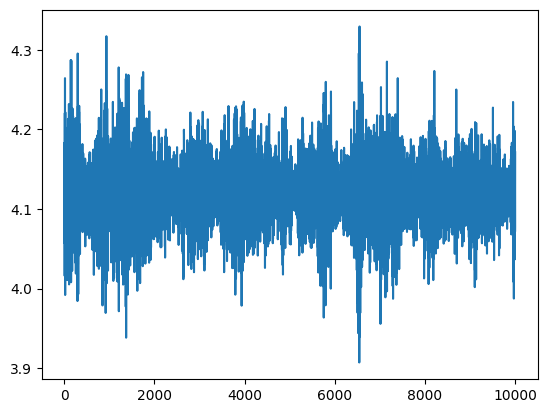

In [8]:
plt.plot(losses)

In [9]:
paths = []
vels = []
for j in np.linspace(0, 1, 2000):
    t = torch.tensor(j).float()
    t = t.unsqueeze(0).repeat(x0.shape[0])
    t = pad_t_like_x(t, x0)
    t.requires_grad_(True)

    gamma = (1 - t**2 - (1-t)**2)
    d_gamma = 2 * (-2 * t + 1)
    phi = model(x0_x1, c, t)
    d_phi = torch.autograd.grad(
            phi,
            t,
            grad_outputs=torch.ones_like(phi),
            create_graph=True,
            retain_graph=True,
        )[0]
    
    xt = (1-t) * x0 + t * x1 + gamma * phi
    ut = x1 - x0 + d_gamma * phi + gamma * d_phi
    
    paths.append(xt.detach())
    vels.append(ut.detach())
paths = torch.stack(paths, dim=0)
vels = torch.stack(vels, dim=0)

In [10]:
print(paths.shape, vels.shape)

torch.Size([2000, 50, 2]) torch.Size([2000, 50, 2])


In [11]:
exact_e = torch.norm(x0 - x1, dim = -1)**2
model_e = torch.mean(torch.norm(vels, dim=2)**2, dim=0)

In [12]:
print(torch.stack([exact_e, model_e], dim=1))

tensor([[ 0.6254,  0.6270],
        [ 0.3933,  0.4121],
        [ 2.9767,  2.9822],
        [ 4.6973,  4.6985],
        [ 7.9398,  7.9330],
        [ 0.9939,  0.9811],
        [ 0.4002,  0.3766],
        [ 1.8240,  1.8045],
        [ 7.4109,  7.4539],
        [ 0.8002,  0.8298],
        [ 0.0370,  0.0427],
        [21.8650, 21.9213],
        [ 1.6518,  1.6266],
        [ 4.4255,  4.4454],
        [ 0.6127,  0.6454],
        [ 1.3488,  1.3424],
        [ 5.7312,  5.7490],
        [ 0.3942,  0.3992],
        [ 8.2802,  8.2629],
        [ 4.5206,  4.4950],
        [ 1.0078,  1.0153],
        [ 1.2411,  1.2091],
        [ 2.9045,  2.8774],
        [ 0.2063,  0.2202],
        [ 2.9001,  2.9023],
        [12.6013, 12.6068],
        [ 1.3192,  1.3256],
        [ 6.2348,  6.2100],
        [ 3.0609,  3.1005],
        [ 9.5090,  9.5631],
        [ 2.8728,  2.8523],
        [ 9.3740,  9.3964],
        [ 4.3603,  4.3221],
        [ 4.9166,  4.9505],
        [ 3.0401,  2.9882],
        [ 2.5340,  2

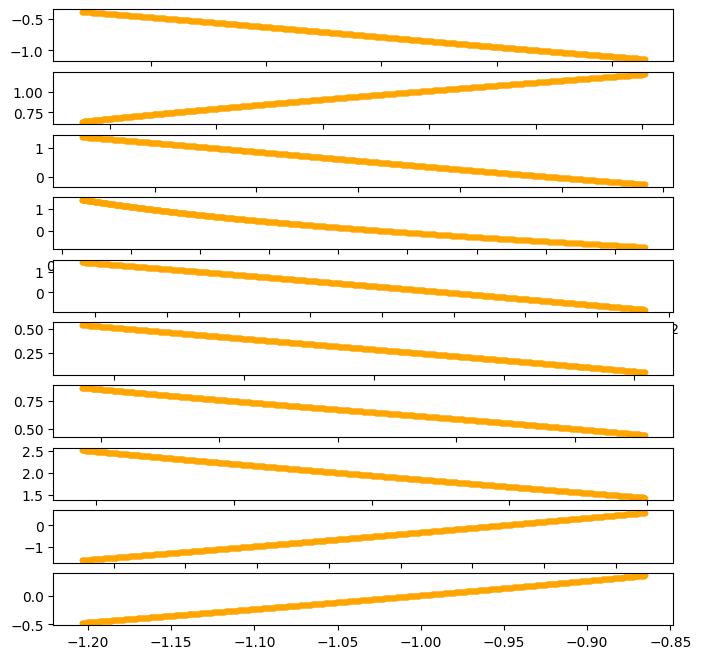

In [17]:
fig, ax = plt.subplots(10, figsize=(8,8))
for i in range(10):
    traj = paths[:,i]
    ax[i].plot(traj[:, 0], traj[:, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
plt.show()